# 1. **Clustering (K-Means)**

**Goal:** Group airports into categories like High-growth, Stable, Declining.

**Steps:**

Aggregate passenger data by airport (compute growth, volatility, share).

Scale features.

Apply K-Means clustering.

Label clusters (business meaning: high-growth, stable, declining).



📂 Please upload mon_pax_web.csv and mon_acm_web.csv...


Saving mon_pax_web.csv to mon_pax_web.csv
Saving mon_acm_web.csv to mon_acm_web.csv

✅ Files uploaded successfully!
Passenger Data Sample:
    AIRPORT  Year  Month  Dom_Pax_In  Dom_Pax_Out  Dom_Pax_Total  Int_Pax_In  \
0  ADELAIDE  1985      1       81661        81630         163291        5806   
1  ADELAIDE  1985      2       67452        64219         131671        4260   
2  ADELAIDE  1985      3       77448        79177         156625        5288   
3  ADELAIDE  1985      4       76105        77891         153996        3346   
4  ADELAIDE  1985      5       83597        88333         171930        3943   

   Int_Pax_Out  Int_Pax_Total  Pax_In  Pax_Out  Pax_Total  
0         4733          10539   87467    86363     173830  
1         3555           7815   71712    67774     139486  
2         5157          10445   82736    84334     167070  
3         4721           8067   79451    82612     162063  
4         5037           8980   87540    93370     180910  

Aircraft Movement D

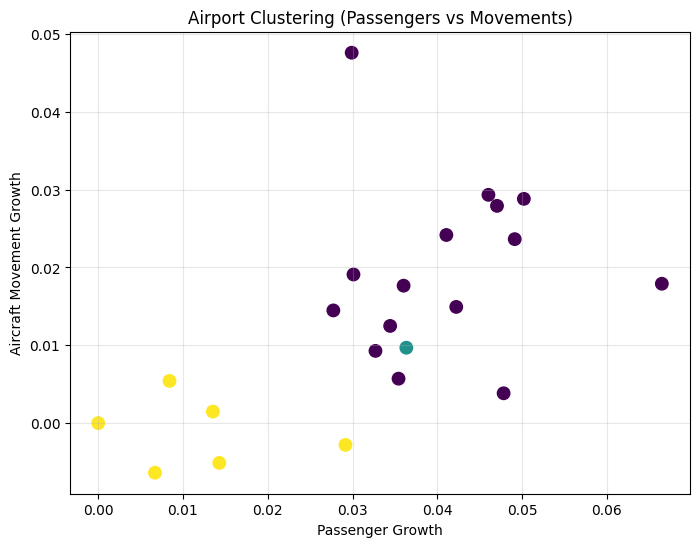

In [ ]:
# ==============================
# STEP 1: Import libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from google.colab import files

# ==============================
# STEP 2: Upload CSV files
# ==============================
print("📂 Please upload mon_pax_web.csv and mon_acm_web.csv...")
uploaded = files.upload()

# Load data
pax = pd.read_csv("mon_pax_web.csv")   # Passenger data
acm = pd.read_csv("mon_acm_web.csv")   # Aircraft movement data

print("\n✅ Files uploaded successfully!")
print("Passenger Data Sample:")
print(pax.head())

print("\nAircraft Movement Data Sample:")
print(acm.head())

# Create a datetime column from Year and Month for accurate merging
pax['Date'] = pd.to_datetime(pax['Year'].astype(str) + '-' + pax['Month'].astype(str) + '-01')
acm['Date'] = pd.to_datetime(acm['Year'].astype(str) + '-' + acm['Month'].astype(str) + '-01')


# ==============================
# STEP 3: Passenger Features
# ==============================
pax_group = pax.groupby("AIRPORT")["Pax_Total"].agg(["sum", "mean", "std"]).reset_index()
pax_group.rename(columns={"sum": "total_passengers", "mean": "avg_passengers", "std": "pax_volatility"}, inplace=True)

# Growth function (CAGR style)
def compute_growth(series):
    first = series.iloc[0]
    last = series.iloc[-1]
    months = len(series)
    if first <= 0:
        return 0
    return ((last / first) ** (12 / months)) - 1

pax_growth = pax.groupby("AIRPORT")["Pax_Total"].apply(compute_growth).reset_index()
pax_growth.rename(columns={"Pax_Total": "pax_growth"}, inplace=True)

pax_features = pd.merge(pax_group, pax_growth, on="AIRPORT")


# ==============================
# STEP 4: Aircraft Movement Features
# ==============================
acm_group = acm.groupby("AIRPORT")["Acm_Total"].agg(["sum", "mean", "std"]).reset_index()
acm_group.rename(columns={"sum": "total_movements", "mean": "avg_movements", "std": "acm_volatility"}, inplace=True)

acm_growth = acm.groupby("AIRPORT")["Acm_Total"].apply(compute_growth).reset_index()
acm_growth.rename(columns={"Acm_Total": "acm_growth"}, inplace=True)

acm_features = pd.merge(acm_group, acm_growth, on="AIRPORT")


# ==============================
# STEP 5: Merge Passenger + Aircraft Features
# ==============================
features = pd.merge(pax_features, acm_features, on="AIRPORT")

X = features[[
    "total_passengers", "avg_passengers", "pax_volatility", "pax_growth",
    "total_movements", "avg_movements", "acm_volatility", "acm_growth"
]]


# ==============================
# STEP 6: Scale features
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ==============================
# STEP 7: Apply K-Means Clustering
# ==============================
kmeans = KMeans(n_clusters=3, random_state=42)
features["cluster"] = kmeans.fit_predict(X_scaled)

# Cluster summary
cluster_summary = features.groupby("cluster")[["pax_growth", "acm_growth"]].mean()
print("\n📊 Cluster Summary:\n", cluster_summary)


# ==============================
# STEP 8: Assign Business Labels
# ==============================
def label_cluster(row, summary):
    cluster = row["cluster"]
    pax_g = summary.loc[cluster, "pax_growth"]
    acm_g = summary.loc[cluster, "acm_growth"]

    if pax_g > 0.1 and acm_g > 0.05:
        return "High-growth"
    elif pax_g < -0.02 or acm_g < -0.02:
        return "Declining"
    else:
        return "Stable"

features["label"] = features.apply(lambda row: label_cluster(row, cluster_summary), axis=1)


# ==============================
# STEP 9: Save Results
# ==============================
features.to_csv("airport_clusters.csv", index=False)
print("\n✅ Results saved as airport_clusters.csv")

print("\nFinal Clustered Airports:")
print(features[["AIRPORT", "pax_growth", "acm_growth", "cluster", "label"]].head())


# ==============================
# STEP 10: Visualization
# ==============================
plt.figure(figsize=(8,6))
plt.scatter(features["pax_growth"], features["acm_growth"], c=features["cluster"], cmap="viridis", s=80)
plt.xlabel("Passenger Growth")
plt.ylabel("Aircraft Movement Growth")
plt.title("Airport Clustering (Passengers vs Movements)")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ==============================
# STEP 7b: Cluster Evaluation Metrics
# ==============================
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

silhouette = silhouette_score(X_scaled, features["cluster"])
davies = davies_bouldin_score(X_scaled, features["cluster"])
calinski = calinski_harabasz_score(X_scaled, features["cluster"])

print("\n📈 Clustering Evaluation Metrics:")
print(f"Silhouette Score: {silhouette:.3f}  (closer to 1 = better separation)")
print(f"Davies-Bouldin Index: {davies:.3f}  (closer to 0 = better)")
print(f"Calinski-Harabasz Index: {calinski:.3f}  (higher = better)")



📈 Clustering Evaluation Metrics:
Silhouette Score: 0.388  (closer to 1 = better separation)
Davies-Bouldin Index: 0.523  (closer to 0 = better)
Calinski-Harabasz Index: 46.491  (higher = better)


# **2. Regression Models**

**Goal**: Predict passenger growth using aircraft movements, seasonality, and lag features.

**Steps**:

Create lag features (lag_1, lag_12).

Add seasonality (month, quarter).

Train a regression model (e.g., Linear Regression, Random Forest, XGBoost).

📂 Please upload mon_pax_web.csv and mon_acm_web.csv...


Saving mon_pax_web.csv to mon_pax_web (7).csv
Saving mon_acm_web.csv to mon_acm_web (7).csv

✅ Files uploaded successfully!
Passenger Data Sample:
    AIRPORT  Year  Month  Dom_Pax_In  Dom_Pax_Out  Dom_Pax_Total  Int_Pax_In  \
0  ADELAIDE  1985      1       81661        81630         163291        5806   
1  ADELAIDE  1985      2       67452        64219         131671        4260   
2  ADELAIDE  1985      3       77448        79177         156625        5288   
3  ADELAIDE  1985      4       76105        77891         153996        3346   
4  ADELAIDE  1985      5       83597        88333         171930        3943   

   Int_Pax_Out  Int_Pax_Total  Pax_In  Pax_Out  Pax_Total       date  
0         4733          10539   87467    86363     173830 1985-01-01  
1         3555           7815   71712    67774     139486 1985-02-01  
2         5157          10445   82736    84334     167070 1985-03-01  
3         4721           8067   79451    82612     162063 1985-04-01  
4         5037   

/tmp/ipython-input-2990916934.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train = df.groupby('AIRPORT', group_keys=False).apply(lambda x: x.iloc[:-12] if len(x) > 12 else x.iloc[:0])
/tmp/ipython-input-2990916934.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test = df.groupby('AIRPORT', group_keys=False).apply(lambda x: x.iloc[-12:] if len(x) > 12 else x.iloc[:0])


📊 Model Performance:
MAE  = 0.0373
RMSE = 0.0514
R²   = 0.7528


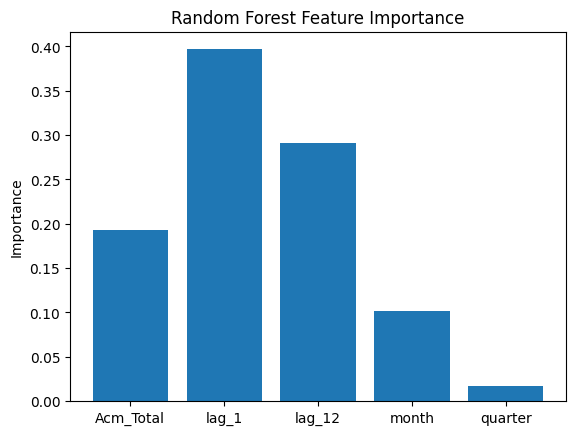

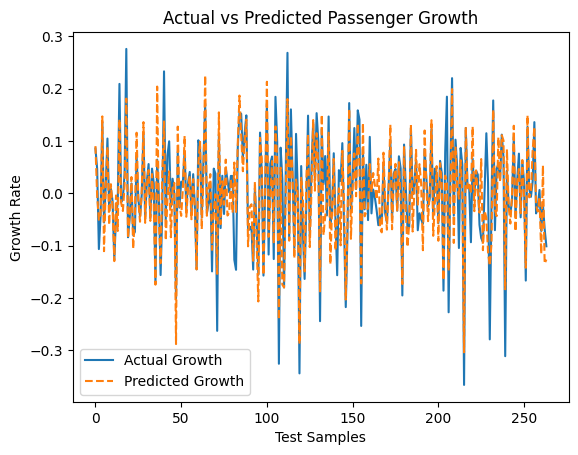

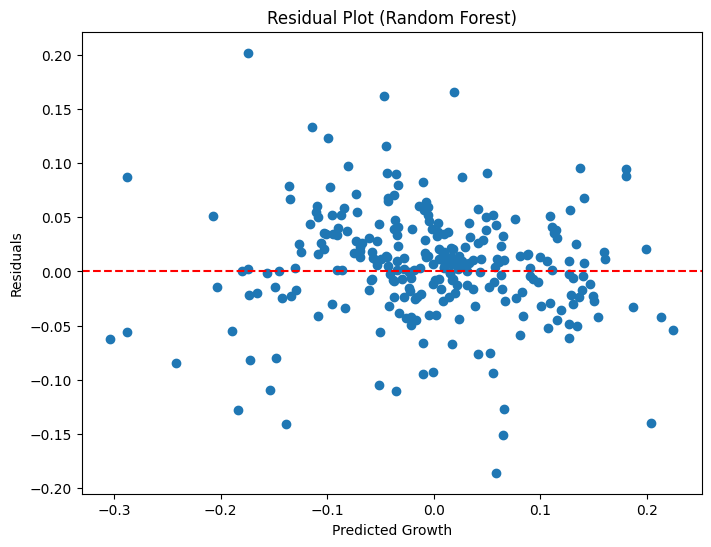

In [ ]:
# 🚀 Airport Passenger Growth Prediction with Random Forest

# ✅ STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

# ✅ STEP 2: LOAD DATASETS
print("📂 Please upload mon_pax_web.csv and mon_acm_web.csv...")
uploaded = files.upload()

# Load data
passenger = pd.read_csv("mon_pax_web.csv")   # Passenger data
aircraft = pd.read_csv("mon_acm_web.csv")   # Aircraft movement data

print("\n✅ Files uploaded successfully!")
print("Passenger Data Sample:")
print(pax.head())

print("\nAircraft Movement Data Sample:")
print(acm.head())

# ✅ STEP 3: MERGE DATASETS ON (AIRPORT, YEAR, MONTH)
df = pd.merge(passenger, aircraft, on=["AIRPORT", "Year", "Month"], how="inner")

# ✅ STEP 4: CREATE A DATE COLUMN
df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# ✅ STEP 5: FEATURE ENGINEERING
df['lag_1'] = df.groupby('AIRPORT')['Pax_Total'].shift(1)
df['lag_12'] = df.groupby('AIRPORT')['Pax_Total'].shift(12)
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

# Target variable = Passenger growth (% change from previous month)
df['growth'] = df.groupby('AIRPORT')['Pax_Total'].pct_change()

# ✅ FIX 1: Remove invalid target values (NaN, inf, -inf)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['growth'])

# ✅ STEP 6: TRAIN-TEST SPLIT (last 12 months = test set)
train = df.groupby('AIRPORT', group_keys=False).apply(lambda x: x.iloc[:-12] if len(x) > 12 else x.iloc[:0])
test = df.groupby('AIRPORT', group_keys=False).apply(lambda x: x.iloc[-12:] if len(x) > 12 else x.iloc[:0])

X_train = train[['Acm_Total','lag_1','lag_12','month','quarter']]
y_train = train['growth']
X_test = test[['Acm_Total','lag_1','lag_12','month','quarter']]
y_test = test['growth']

# ✅ FIX 2: Drop any remaining NA rows in features
train_idx = X_train.dropna().index
test_idx = X_test.dropna().index
X_train, y_train = X_train.loc[train_idx], y_train.loc[train_idx]
X_test, y_test = X_test.loc[test_idx], y_test.loc[test_idx]

# ✅ STEP 7: TRAIN RANDOM FOREST MODEL
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# ✅ STEP 8: PREDICTIONS
y_pred = rf.predict(X_test)

# ✅ STEP 9: EVALUATION METRICS
mae = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📊 Model Performance:")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

# ✅ STEP 10: FEATURE IMPORTANCE VISUALIZATION
importances = rf.feature_importances_
features = ['Acm_Total','lag_1','lag_12','month','quarter']

plt.bar(features, importances)
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()

# ✅ STEP 11: COMPARE ACTUAL vs PREDICTED
plt.plot(y_test.values, label="Actual Growth")
plt.plot(y_pred, label="Predicted Growth", linestyle="--")
plt.title("Actual vs Predicted Passenger Growth")
plt.xlabel("Test Samples")
plt.ylabel("Growth Rate")
plt.legend()
plt.show()

# # ✅ STEP 12: Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (Random Forest)")
plt.xlabel("Predicted Growth")
plt.ylabel("Residuals")
plt.show()


# **3. Anomaly Detection**

**Goal**: Flag unusual traffic drops (e.g., COVID, strikes, sudden spikes).

**Approaches**:

Forecast residuals (compare actual vs predicted).

Unsupervised anomaly detection (Isolation Forest).

📂 Please upload mon_pax_web.csv and mon_acm_web.csv...


Saving mon_pax_web.csv to mon_pax_web (9).csv
Saving mon_acm_web.csv to mon_acm_web (9).csv

✅ Files uploaded successfully!
Passenger Data Sample:
    AIRPORT  Year  Month  Dom_Pax_In  Dom_Pax_Out  Dom_Pax_Total  Int_Pax_In  \
0  ADELAIDE  1985      1       81661        81630         163291        5806   
1  ADELAIDE  1985      2       67452        64219         131671        4260   
2  ADELAIDE  1985      3       77448        79177         156625        5288   
3  ADELAIDE  1985      4       76105        77891         153996        3346   
4  ADELAIDE  1985      5       83597        88333         171930        3943   

   Int_Pax_Out  Int_Pax_Total  Pax_In  Pax_Out  Pax_Total  
0         4733          10539   87467    86363     173830  
1         3555           7815   71712    67774     139486  
2         5157          10445   82736    84334     167070  
3         4721           8067   79451    82612     162063  
4         5037           8980   87540    93370     180910  

Aircraft Mo

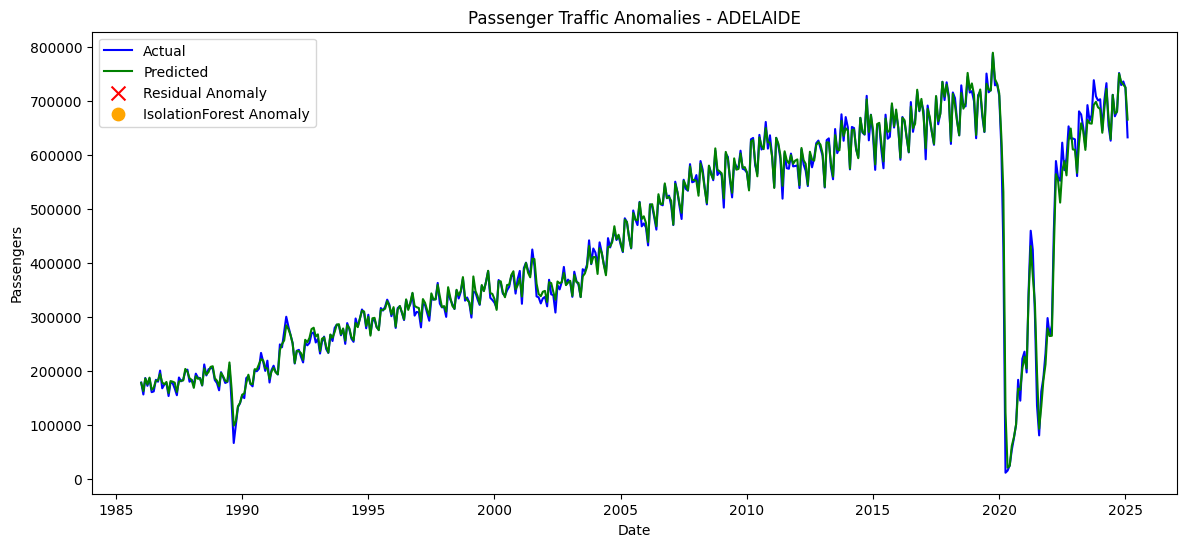

✅ Anomalies saved to airport_anomalies.csv


In [ ]:
# 📌 Anomaly Detection with Evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# ✅ Load Data
print("📂 Please upload mon_pax_web.csv and mon_acm_web.csv...")
uploaded = files.upload()

# Load data
pax = pd.read_csv("mon_pax_web.csv")   # Passenger data
acm = pd.read_csv("mon_acm_web.csv")   # Aircraft movement data

print("\n✅ Files uploaded successfully!")
print("Passenger Data Sample:")
print(pax.head())

print("\nAircraft Movement Data Sample:")
print(acm.head())

df = pd.merge(
    pax, acm,
    on=["AIRPORT", "Year", "Month"],
    suffixes=("_pax", "_acm")
)

df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")
df = df.sort_values(["AIRPORT", "Date"]).reset_index(drop=True)

# ✅ Feature Engineering
df["Quarter"] = df["Month"].apply(lambda x: (x-1)//3 + 1)
df["lag_1"] = df.groupby("AIRPORT")["Pax_Total"].shift(1)
df["lag_12"] = df.groupby("AIRPORT")["Pax_Total"].shift(12)
df = df.dropna().reset_index(drop=True)

features = ["Acm_Total", "Month", "Quarter", "lag_1", "lag_12"]
target = "Pax_Total"

# ✅ Train Random Forest for residual-based anomalies
X = df[features]
y = df[target]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)
df["y_pred"] = rf.predict(X)

# Residuals
df["residual"] = df[target] - df["y_pred"]

# Residual anomaly threshold (2σ)
threshold = 2 * df["residual"].std()
df["residual_anomaly"] = (abs(df["residual"]) > threshold).astype(int)

# ✅ Isolation Forest Anomalies
iso = IsolationForest(contamination=0.05, random_state=42)
df["iso_anomaly"] = iso.fit_predict(df[features])
df["iso_anomaly"] = df["iso_anomaly"].map({1:0, -1:1})

# ✅ Evaluation
if "anomaly_label" in df.columns:  # Case (a): Ground truth available
    print("📌 Ground Truth Evaluation (Supervised):")
    for method in ["residual_anomaly", "iso_anomaly"]:
        prec = precision_score(df["anomaly_label"], df[method])
        rec = recall_score(df["anomaly_label"], df[method])
        f1 = f1_score(df["anomaly_label"], df[method])
        cm = confusion_matrix(df["anomaly_label"], df[method])
        print(f"\n🔎 {method}:")
        print(f"Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")
        print("Confusion Matrix:\n", cm)

else:  # Case (b): No ground truth
    print("📌 No Ground Truth → Business Sanity Evaluation")
    res_rate = df["residual_anomaly"].mean() * 100
    iso_rate = df["iso_anomaly"].mean() * 100
    overlap = ((df["residual_anomaly"]==1) & (df["iso_anomaly"]==1)).mean() * 100

    print(f"Residual anomalies flagged: {res_rate:.2f}%")
    print(f"IsolationForest anomalies flagged: {iso_rate:.2f}%")
    print(f"Overlap anomalies (both methods agree): {overlap:.2f}%")

# ✅ Visualization Example
airport = df["AIRPORT"].unique()[0]  # Example: first airport
sub = df[df["AIRPORT"] == airport]

plt.figure(figsize=(14,6))
plt.plot(sub["Date"], sub["Pax_Total"], label="Actual", color="blue")
plt.plot(sub["Date"], sub["y_pred"], label="Predicted", color="green")

plt.scatter(sub["Date"][sub["residual_anomaly"]==1],
            sub["Pax_Total"][sub["residual_anomaly"]==1],
            color="red", label="Residual Anomaly", marker="x", s=100)

plt.scatter(sub["Date"][sub["iso_anomaly"]==1],
            sub["Pax_Total"][sub["iso_anomaly"]==1],
            color="orange", label="IsolationForest Anomaly", marker="o", s=80)

plt.title(f"Passenger Traffic Anomalies - {airport}")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

# ✅ Save Anomalies
anomalies = df[(df["residual_anomaly"]==1) | (df["iso_anomaly"]==1)]
anomalies.to_csv("airport_anomalies.csv", index=False)
print("✅ Anomalies saved to airport_anomalies.csv")
